## **Q) Compare the performance of the K-means clustering algorithm with the DBSCAN algorithm.**


DBSCAN – PERFORMANCE COMPARISON

   Epsilon  MinPts  Clusters  Noise Points  Silhouette     ARI
0      0.4       5         2            31      0.5225  0.3916
1      0.6       5         1             5         NaN -0.0002
2      0.8       5         1             3         NaN  0.0011


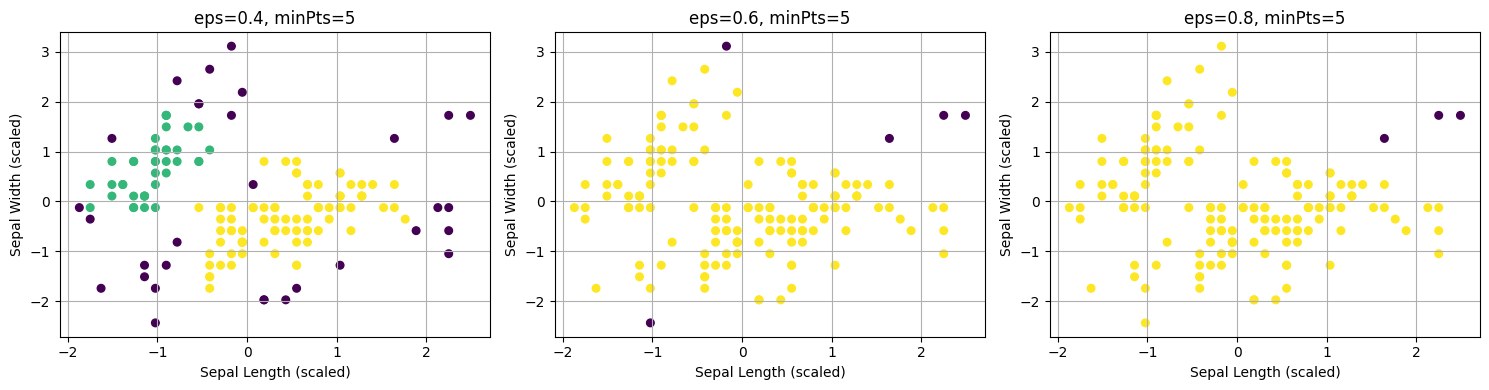

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1. Load Iris Dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df = pd.read_csv(url, header=None, names=columns)

# Use two features
X = df[["sepal_length", "sepal_width"]].values
y_true = df["class"].values

# 2. Feature Scaling

scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. DBSCAN

def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def region_query(X, idx, eps):
    neighbors = []
    for i in range(len(X)):
        if euclidean_distance(X[idx], X[i]) <= eps:
            neighbors.append(i)
    return neighbors

def expand_cluster(X, labels, idx, neighbors, cluster_id, eps, min_pts):
    labels[idx] = cluster_id
    i = 0

    while i < len(neighbors):
        n_idx = neighbors[i]

        if labels[n_idx] == -1:
            labels[n_idx] = cluster_id

        if labels[n_idx] == 0:
            labels[n_idx] = cluster_id
            new_neighbors = region_query(X, n_idx, eps)
            if len(new_neighbors) >= min_pts:
                neighbors += new_neighbors
        i += 1

def dbscan_scratch(X, eps, min_pts):
    labels = np.zeros(len(X))
    cluster_id = 0

    for i in range(len(X)):
        if labels[i] != 0:
            continue

        neighbors = region_query(X, i, eps)

        if len(neighbors) < min_pts:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(X, labels, i, neighbors, cluster_id, eps, min_pts)

    return labels

# 4. Different Parameter Configurations

configs = [
    {"eps": 0.4, "min_pts": 5},
    {"eps": 0.6, "min_pts": 5},
    {"eps": 0.8, "min_pts": 5}
]

results = []

# 5. Performance Evaluation

for cfg in configs:
    labels = dbscan_scratch(X, cfg["eps"], cfg["min_pts"])

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Silhouette
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan

    ari = adjusted_rand_score(y_true, labels)

    results.append([
        cfg["eps"],
        cfg["min_pts"],
        n_clusters,
        n_noise,
        sil,
        ari
    ])

# 6. Results Table

results_df = pd.DataFrame(
    results,
    columns=["Epsilon", "MinPts", "Clusters", "Noise Points", "Silhouette", "ARI"]
)

print("\nDBSCAN – PERFORMANCE COMPARISON\n")
print(results_df.round(4))

# 7. Visualization

plt.figure(figsize=(15, 4))

for i, cfg in enumerate(configs):
    labels = dbscan_scratch(X, cfg["eps"], cfg["min_pts"])

    plt.subplot(1, 3, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=30)
    plt.title(f"eps={cfg['eps']}, minPts={cfg['min_pts']}")
    plt.xlabel("Sepal Length (scaled)")
    plt.ylabel("Sepal Width (scaled)")
    plt.grid(True)

plt.tight_layout()
plt.show()
